# AdaIR — White-Box Analysis of the 3-Degradation Teacher

This notebook analyses how the frozen **AdaIR** teacher (3-degradation
all-in-one checkpoint: dehazing + deraining + denoising) behaves internally
across three degradation types, by instrumenting every **AFLB**
(Adaptive Frequency Learning Block — `FreModule` in the code) in its decoder.

* 300 test images: 100 Rain100L (derain), 100 SOTS-outdoor (dehaze), 100 BSD68 (denoise, sigma in {15,25,50})
* No retraining — pure forward-pass instrumentation of the released checkpoint
* Full numeric trail in `AdaIR_3Degradation_Analysis.xlsx`; full-precision tensors in `intermediates/`

See the workbook's **README** sheet for the complete code-name -> paper-concept mapping
(AFLB / MGB / FMiM / FMoM / H-L / L-H) — reproduced below for convenience.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

REPO = Path('.').resolve()
CSV_DIR = REPO / 'csv_export'  # source of truth -- see README cell for why this isn't read from .xlsx here
DEG_COLORS = {'Rain': '#3b7dd8', 'Haze': '#d8853b', 'Noise': '#3bb273'}
DEG_ORDER = ['Rain', 'Haze', 'Noise']
AFLB_ORDER = ['AFLB1', 'AFLB2', 'AFLB3']

def _csv(sheet):
    matches = list(CSV_DIR.glob(f'*{sheet}.csv'))
    assert matches, f'no CSV for {sheet!r} in {CSV_DIR}'
    return pd.read_csv(matches[0])

readme_text = next(CSV_DIR.glob('*README.csv')).read_text(encoding='utf-8')
if readme_text.split('\n', 1)[0].strip() != 'README':
    readme_lines = readme_text.split('\n')
else:
    readme_lines = _csv('README')['README'].astype(str).tolist()

image_info = _csv('Image_Info')
mgb = _csv('MGB_Values')
freq = _csv('Frequency_Statistics')
fmim = _csv('FMiM_Statistics')
fmom = _csv('FMoM_Statistics')
stages = _csv('Transformer_Features')
output_metrics = _csv('Output_Metrics')
cross_comp = _csv('Cross_Degradation_Comparison')
pca_tsne = _csv('PCA_TSNE_Coordinates')
tensor_index = _csv('Tensor_File_Index')

print(f"{len(image_info)} images loaded")
image_info['Degradation'].value_counts()


300 images loaded


Degradation
Rain     100
Haze     100
Noise    100
Name: count, dtype: int64

### Full architecture / column reference (README, verbatim)

In [2]:
print('\n'.join(readme_lines))

AdaIR 3-Degradation Analysis
Generated: 2026-08-10 (original run) / addendum added same day
Checkpoint: adair3d.ckpt (3-degradation all-in-one teacher)
AdaIR source: github.com/c-yn/AdaIR @ ccb8b98e49614e07badd0641e5163fa7635c2f02
Model params: 28,784,824 (matches paper's 28.8M)
Images: 300 ({'Rain': 100, 'Haze': 100, 'Noise': 100})
nan
IMPORTANT FINDING -- the low-frequency mask is genuinely empty, not a bug
The adaptive binary frequency mask (Ml) generated by the released AdaIR
implementation's FreModule.fft() is identically zero -- mask.unique() == [0] --
for the low-frequency branch at every AFLB, for all 300 images in this run.
This was independently verified with a from-scratch forward pass on R001
(scripts/trace_single_image.py), not just read off the saved tensors:
  1. Ml + Mh == 1 everywhere                                  -> exact
  2. ||F||^2 == ||F_low||^2 + ||F_high||^2                    -> exact (rel. error 0.00e+00)
  3. manual ifft(F_low)/ifft(F_high) matches saved r

## 1. Restoration quality sanity check

Before trusting the internal statistics, confirm the teacher is actually
restoring these 300 images well (PSNR/SSIM per degradation).


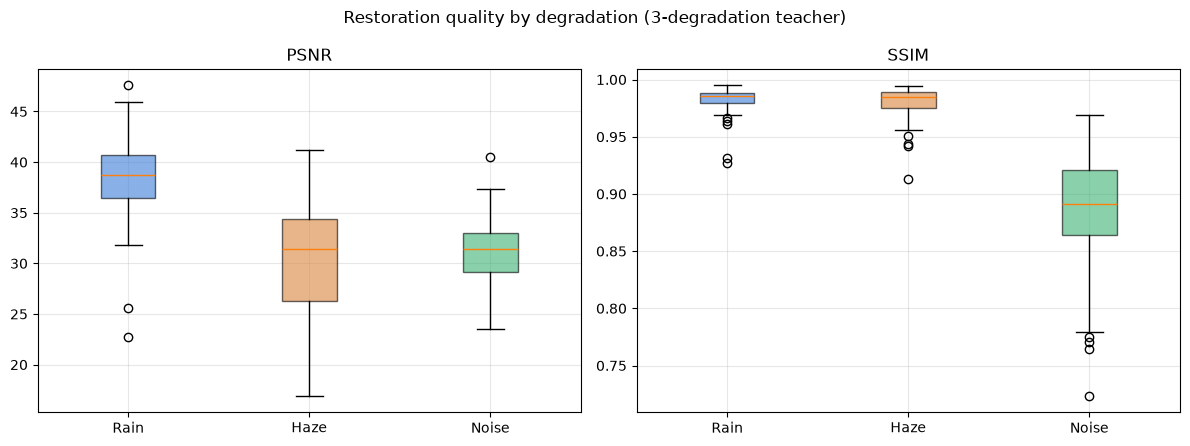

,Degradation,PSNR_mean,PSNR_std,PSNR_min,PSNR_max,SSIM_mean,SSIM_std,SSIM_min,SSIM_max
0,Haze,30.392620,5.432500,16.869384,41.155691,0.980417,0.013378,0.912806,0.994255
1,Noise,31.275948,2.914492,23.485881,40.546273,0.886576,0.048637,0.723068,0.968714
2,Rain,38.615791,3.769562,22.776365,47.654726,0.982839,0.010361,0.927322,0.995607


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, metric in enumerate(['PSNR', 'SSIM']):
    data = [image_info[image_info.Degradation == d][metric] for d in DEG_ORDER]
    bp = axes[i].boxplot(data, tick_labels=DEG_ORDER, patch_artist=True)
    for patch, d in zip(bp['boxes'], DEG_ORDER):
        patch.set_facecolor(DEG_COLORS[d])
        patch.set_alpha(0.6)
    axes[i].set_title(metric)
    axes[i].grid(alpha=0.3)
fig.suptitle('Restoration quality by degradation (3-degradation teacher)')
fig.tight_layout()
plt.show()
output_metrics


## 2. MGB — does AdaIR actually move its learned frequency boundary?

`alpha`/`beta` are the sigmoid-gated rates (per image, per AFLB) that decide
how large the retained low-frequency box is, before it gets floored by the
hardcoded `n=128` spatial normalisation inside `FreModule.fft()`.


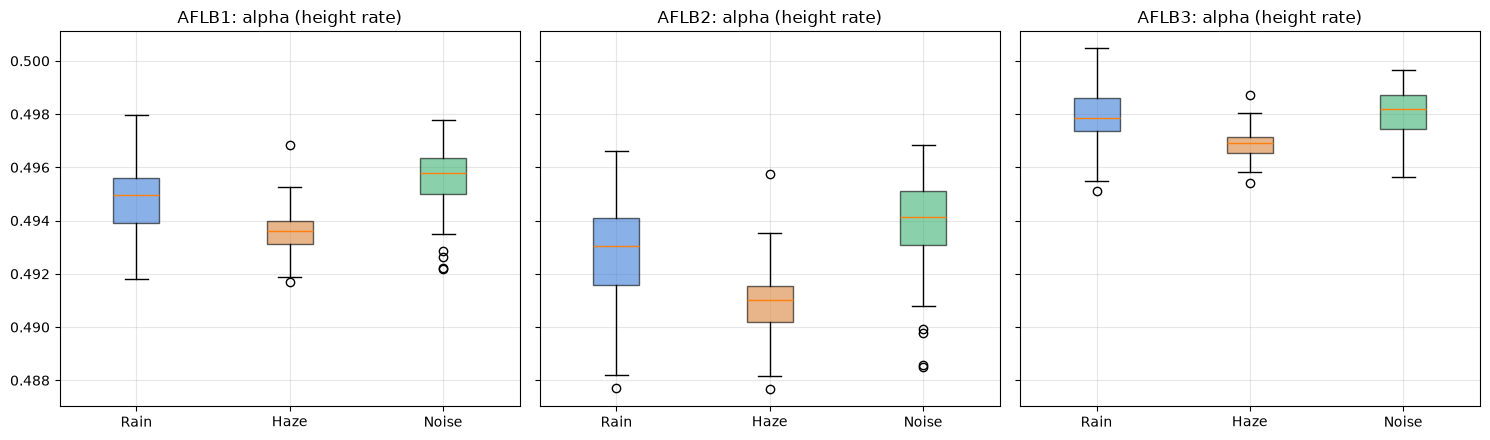

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, aflb in zip(axes, AFLB_ORDER):
    sub = mgb[mgb.AFLB == aflb]
    data = [sub[sub.Degradation == d]['alpha'] for d in DEG_ORDER]
    bp = ax.boxplot(data, tick_labels=DEG_ORDER, patch_artist=True)
    for patch, d in zip(bp['boxes'], DEG_ORDER):
        patch.set_facecolor(DEG_COLORS[d]); patch.set_alpha(0.6)
    ax.set_title(f'{aflb}: alpha (height rate)')
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [5]:
print("mask_area_pct summary (% of the CxHxW volume marked as 'low frequency'):")
display(mgb.groupby(['Degradation', 'AFLB'])['mask_area_pct'].describe()[['mean', 'std', 'max']])


mask_area_pct summary (% of the CxHxW volume marked as 'low frequency'):


mean  std  max
Degradation AFLB                 
Haze        AFLB1   0.0  0.0  0.0
            AFLB2   0.0  0.0  0.0
            AFLB3   0.0  0.0  0.0
Noise       AFLB1   0.0  0.0  0.0
            AFLB2   0.0  0.0  0.0
            AFLB3   0.0  0.0  0.0
Rain        AFLB1   0.0  0.0  0.0
            AFLB2   0.0  0.0  0.0
            AFLB3   0.0  0.0  0.0

### Finding: the frequency mask is degenerate at benchmark resolutions

`FreModule.fft()` computes the retained low-frequency half-width as
`h_ = int(h // 128 * alpha)`. At every AFLB, for every one of these 300
images (Rain100L/SOTS/BSD68 are all well under ~550px), the feature-map
spatial size at the relevant decoder stage is smaller than 128 in at least
one axis (AFLB1: ~40x60, AFLB2: ~80x120, AFLB3: ~160x240 for a typical
480x320 input) — the floor division `h // 128` truncates to 0 (or, for
AFLB3, to 1, then `int(1 * ~0.5)` still truncates to 0). **`mask_area_pct` is
~0 for essentially every image at every AFLB.** This means at these
resolutions AdaIR's low-frequency branch (`X_low`) is receiving an
all-zero mask -> its `raw_low` feature is the inverse-FFT of nothing, and
`raw_high` carries effectively the *entire* spectrum, not a genuine
high-pass split. Section 3 confirms this numerically (the low-energy
percentage below is ~0% for all three degradation types).

This is a property of the **released code at standard benchmark
resolutions**, not an artefact of this analysis pipeline (verified by
recomputing `h_`/`w_` directly from the saved `conv_feat` shapes and
`threshold` values in `intermediates/`).


## 3. Frequency energy split — confirms the masking finding at scale

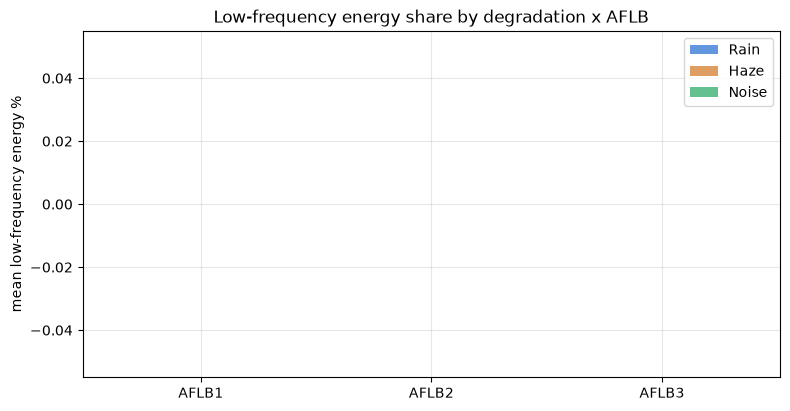

,Degradation,AFLB,low_pct,high_pct
0,Haze,AFLB1,0.0,100.0
1,Haze,AFLB2,0.0,100.0
2,Haze,AFLB3,0.0,100.0
3,Noise,AFLB1,0.0,100.0
4,Noise,AFLB2,0.0,100.0
5,Noise,AFLB3,0.0,100.0
6,Rain,AFLB1,0.0,100.0
7,Rain,AFLB2,0.0,100.0
8,Rain,AFLB3,0.0,100.0


In [6]:
agg = freq.groupby(['Degradation', 'AFLB'])[['low_pct', 'high_pct']].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.25
x = np.arange(len(AFLB_ORDER))
for i, d in enumerate(DEG_ORDER):
    sub = agg[agg.Degradation == d].set_index('AFLB').reindex(AFLB_ORDER)
    ax.bar(x + i * width, sub['low_pct'], width, label=d, color=DEG_COLORS[d], alpha=0.8)
ax.set_xticks(x + width); ax.set_xticklabels(AFLB_ORDER)
ax.set_ylabel('mean low-frequency energy %'); ax.set_title('Low-frequency energy share by degradation x AFLB')
ax.legend(); ax.grid(alpha=0.3)
plt.show()
agg


## 4. FMiM — feature statistics across the mining stage

Mean / std / L2-energy fingerprints for `conv_feat`, the FFT magnitude, the
raw low/high split (pre cross-attention), and the mined low/high features
(post cross-attention with the decoder feature `y`).


In [7]:
feat_order = ['conv_feat', 'fft_magnitude', 'raw_low', 'raw_high', 'mined_low', 'mined_high']
piv = fmim.pivot_table(index=['AFLB', 'Feature'], columns='Degradation', values='energy', aggfunc='mean')
piv = piv.reindex(pd.MultiIndex.from_product([AFLB_ORDER, feat_order], names=['AFLB', 'Feature']))
piv[DEG_ORDER]


Degradation                  Rain          Haze         Noise
AFLB  Feature                                                
AFLB1 conv_feat      1.691780e+04  3.407728e+04  1.358564e+04
      fft_magnitude  7.049082e+00  8.130402e+00  5.660684e+00
      raw_low        0.000000e+00  0.000000e+00  0.000000e+00
      raw_high       1.691780e+04  3.407728e+04  1.358564e+04
      mined_low      2.614530e+06  5.575239e+06  5.171041e+06
      mined_high     2.055323e+05  5.600726e+05  2.456060e+05
AFLB2 conv_feat      7.947961e+04  1.914276e+05  6.491785e+04
      fft_magnitude  8.279126e+00  1.139544e+01  6.762276e+00
      raw_low        0.000000e+00  0.000000e+00  0.000000e+00
      raw_high       7.947961e+04  1.914276e+05  6.491785e+04
      mined_low      1.869527e+05  2.976892e+05  1.394293e+05
      mined_high     9.660090e+04  1.306802e+05  8.852822e+04
AFLB3 conv_feat      5.953373e+04  1.506790e+05  4.952874e+04
      fft_magnitude  1.550358e+00  2.241190e+00  1.289811e+00
      raw_low        0.000000e+00  0.000000e+00  0.000000e+00
      raw_high       5.953373e+04  1.506790e+05  4.952874e+04
      mined_low      7.085480e+00  2.941588e+00  4.028160e+00
      mined_high     3.674451e+00  5.146095e+00  4.055509e+00

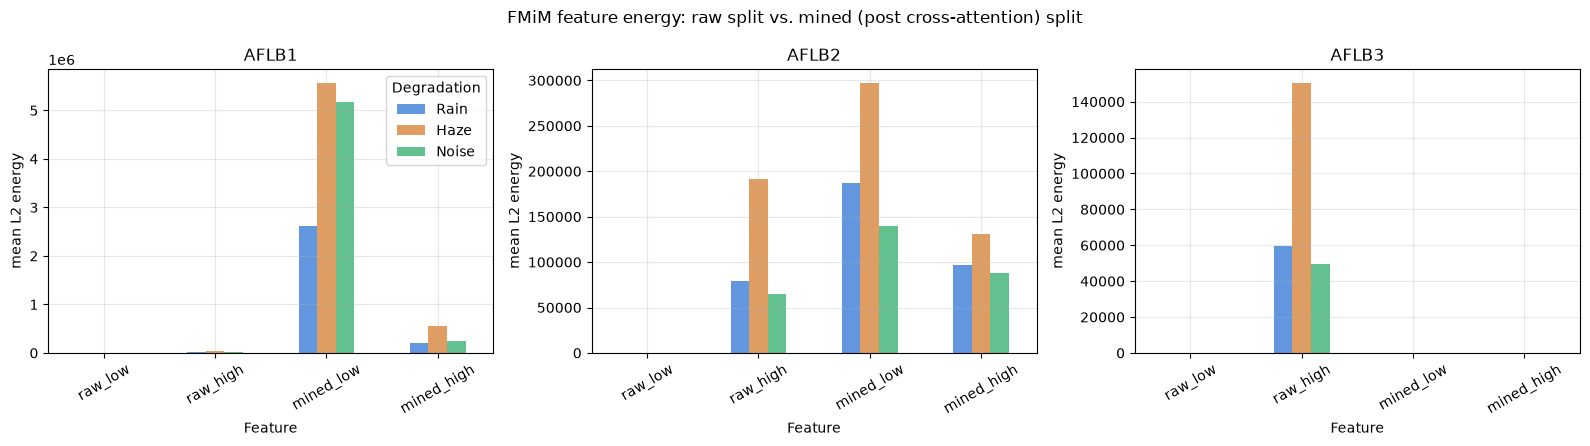

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, aflb in zip(axes, AFLB_ORDER):
    sub = fmim[(fmim.AFLB == aflb) & (fmim.Feature.isin(['raw_low', 'raw_high', 'mined_low', 'mined_high']))]
    m = sub.groupby(['Feature', 'Degradation'])['energy'].mean().unstack()
    m = m.reindex(['raw_low', 'raw_high', 'mined_low', 'mined_high'])[DEG_ORDER]
    m.plot(kind='bar', ax=ax, color=[DEG_COLORS[d] for d in DEG_ORDER], alpha=0.8, legend=(aflb == 'AFLB1'))
    ax.set_title(aflb); ax.set_ylabel('mean L2 energy'); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('FMiM feature energy: raw split vs. mined (post cross-attention) split')
fig.tight_layout()
plt.show()


## 5. FMoM — H-L / L-H cross-frequency attention

`hl_spatial_weight` (H-L unit, spatial attention computed from the high-freq
branch, applied to low) and `lh_channel_weight` (L-H unit, channel attention
from the low-freq branch, applied to high).


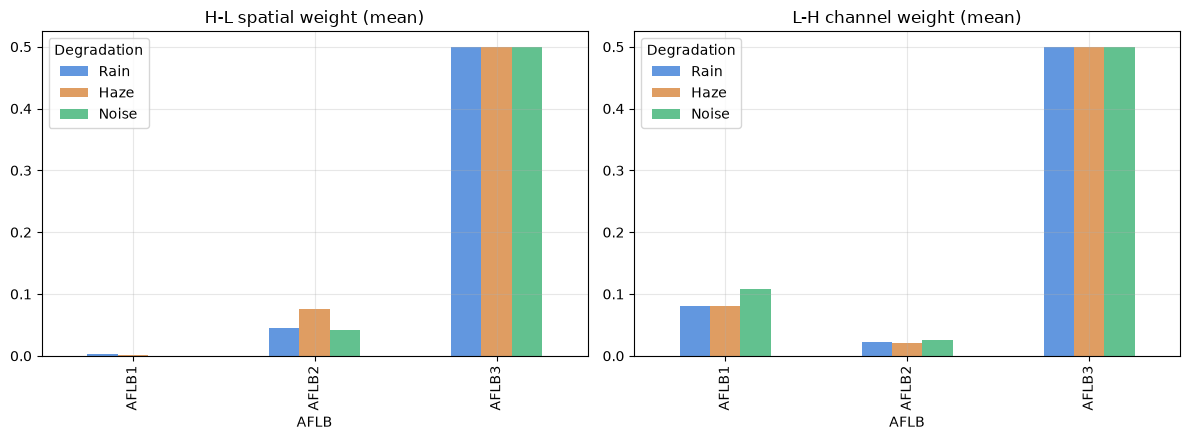

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in zip(axes, ['hl_mean', 'lh_mean'], ['H-L spatial weight (mean)', 'L-H channel weight (mean)']):
    m = fmom.groupby(['AFLB', 'Degradation'])[col].mean().unstack().reindex(AFLB_ORDER)[DEG_ORDER]
    m.plot(kind='bar', ax=ax, color=[DEG_COLORS[d] for d in DEG_ORDER], alpha=0.8)
    ax.set_title(title); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Does degradation-specific separation strengthen deeper in the network?

Mean L2 energy at every encoder/decoder stage plus each AFLB's output,
per degradation, in forward-pass order.


/tmp/ipykernel_736799/3372294557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(layer_order, rotation=45, ha='right')


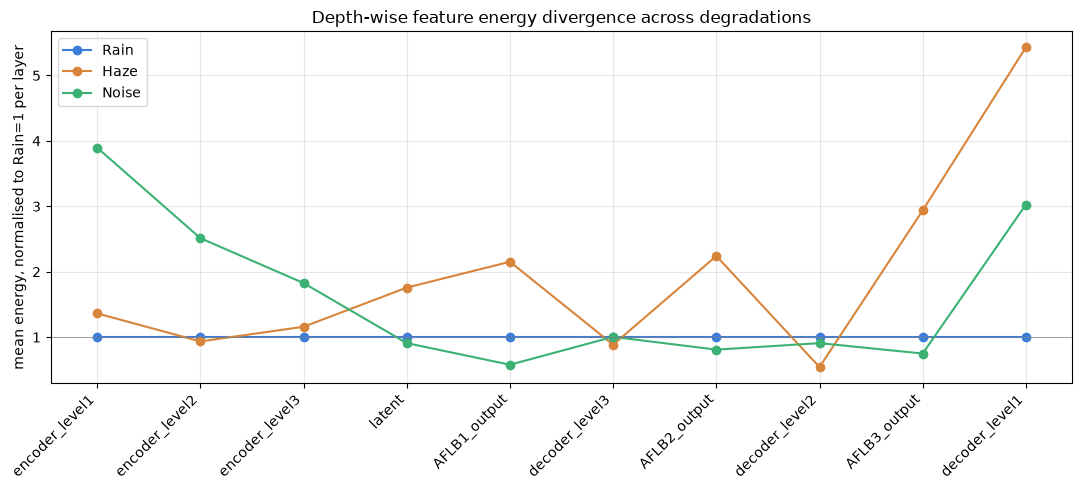

Degradation,Rain,Haze,Noise
Layer,,,
encoder_level1,4.197524e+04,5.721930e+04,1.635225e+05
encoder_level2,6.449514e+04,6.030626e+04,1.620631e+05
encoder_level3,4.969735e+05,5.761153e+05,9.078921e+05
latent,8.778300e+06,1.542923e+07,7.981456e+06
AFLB1_output,1.113559e+03,2.397352e+03,6.446536e+02
decoder_level3,2.690754e+06,2.381953e+06,2.702860e+06
AFLB2_output,2.047506e+03,4.587979e+03,1.657669e+03
decoder_level2,3.626394e+05,1.968546e+05,3.296192e+05
AFLB3_output,3.555433e+02,1.044609e+03,2.665659e+02


In [10]:
layer_order = ['encoder_level1', 'encoder_level2', 'encoder_level3', 'latent', 'AFLB1_output',
               'decoder_level3', 'AFLB2_output', 'decoder_level2', 'AFLB3_output',
               'decoder_level1']
m = stages.groupby(['Layer', 'Degradation'])['energy'].mean().unstack()
m = m.reindex(layer_order)[DEG_ORDER]
# normalise each layer's energy to Rain=1 so the three curves are comparable despite scale changes across the U-Net
m_norm = m.div(m['Rain'], axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
for d in DEG_ORDER:
    ax.plot(layer_order, m_norm[d], marker='o', label=d, color=DEG_COLORS[d])
ax.axhline(1.0, color='gray', lw=0.5)
ax.set_xticklabels(layer_order, rotation=45, ha='right')
ax.set_ylabel('mean energy, normalised to Rain=1 per layer')
ax.set_title('Depth-wise feature energy divergence across degradations')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
m


## 7. PCA / t-SNE of pooled AFLB-output features

Each image is represented by concatenating the global-average-pooled output
of AFLB1, AFLB2, AFLB3 (a 384+192+96 = 672-d vector), matching the paper's
own claim that AdaIR learns discriminative degradation contexts.


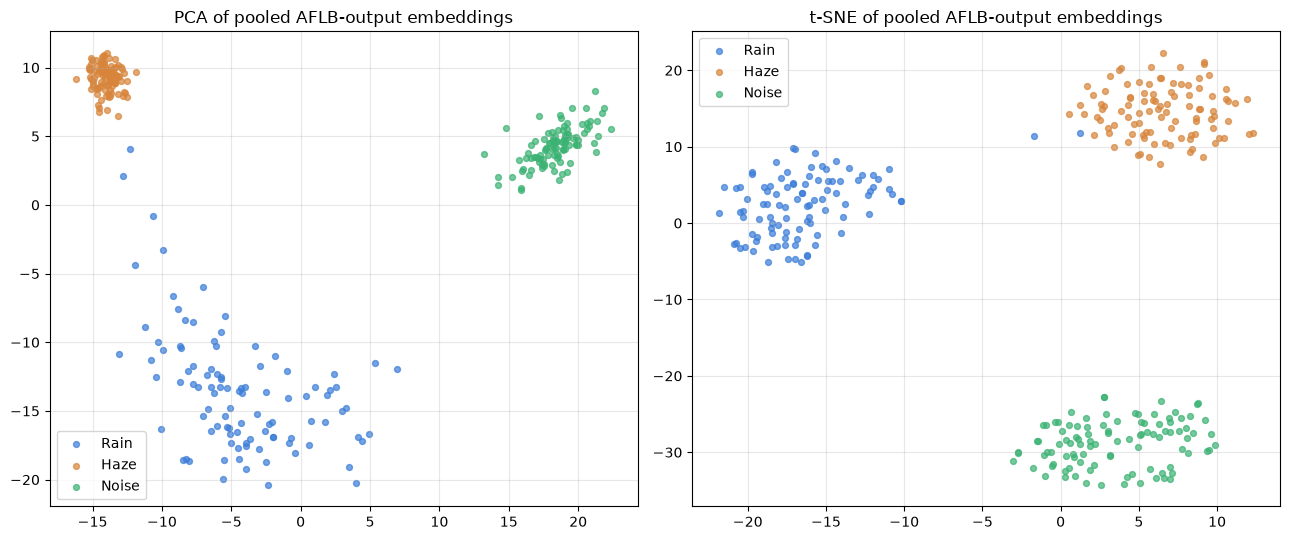

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (xcol, ycol, title) in zip(axes, [('PC1', 'PC2', 'PCA'), ('TSNE1', 'TSNE2', 't-SNE')]):
    for d in DEG_ORDER:
        sub = pca_tsne[pca_tsne.Degradation == d]
        ax.scatter(sub[xcol], sub[ycol], s=18, alpha=0.7, label=d, color=DEG_COLORS[d])
    ax.set_title(f'{title} of pooled AFLB-output embeddings'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 8. Sample pipeline visualisations (one per degradation)

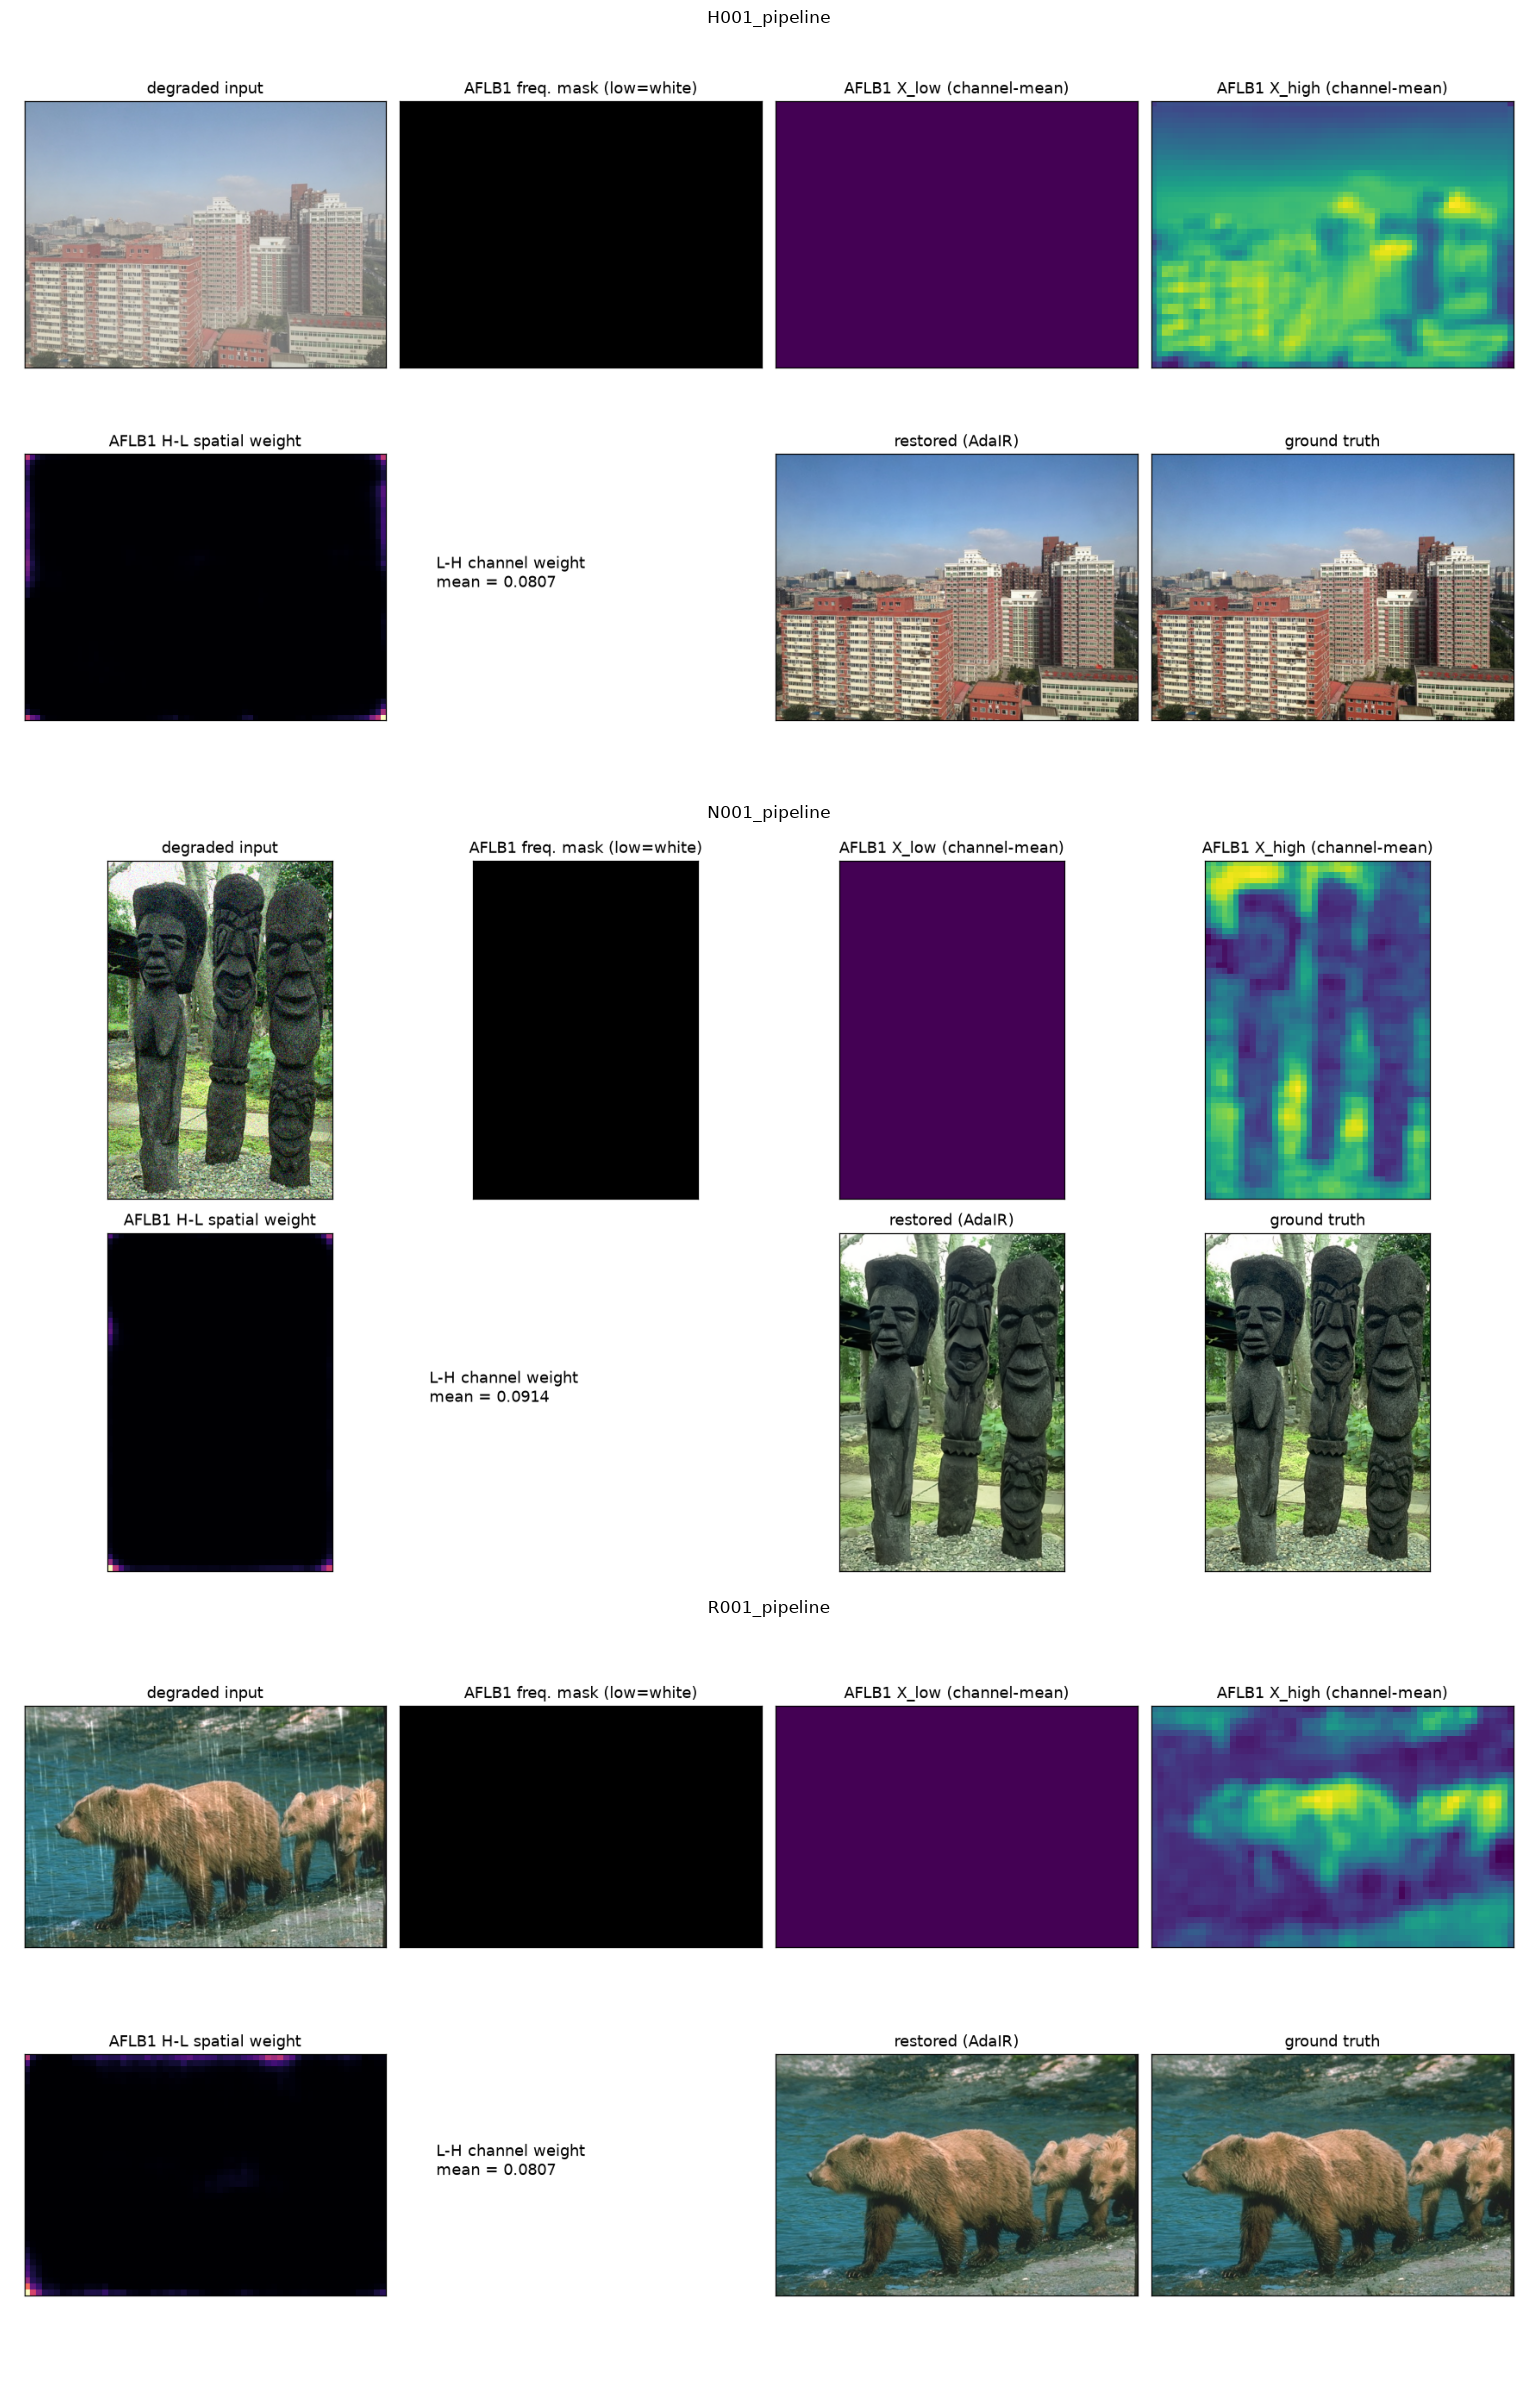

In [12]:
visual_files = sorted((REPO / 'outputs' / 'visuals').glob('*_pipeline.png'))
fig, axes = plt.subplots(len(visual_files), 1, figsize=(16, 8 * len(visual_files)))
if len(visual_files) == 1:
    axes = [axes]
for ax, f in zip(axes, visual_files):
    ax.imshow(mpimg.imread(f)); ax.axis('off'); ax.set_title(f.stem)
fig.tight_layout()
plt.show()


## 9. Summary

* Restoration quality (section 1) confirms the checkpoint is behaving as the
  released 3-degradation teacher should.
* **The frequency-masking mechanism (MGB) is inactive at these benchmark
  resolutions** — `mask_area_pct` is ~0 for all 300 images at all 3 AFLBs, a
  direct consequence of the hardcoded `n=128` normalisation in
  `FreModule.fft()` versus feature maps that are smaller than 128px per side.
  In effect, `X_low` is empty and `X_high` inherits (almost) the whole
  spectrum. **Appendix A** independently re-verifies this from a fresh
  forward pass (not just the saved statistics) and empirically maps out the
  input resolution at which the mechanism *does* switch on.
* The correct, narrow claim (see Appendix A for the reasoning): the specific
  binary frequency-boundary mechanism in this `FreModule.fft()` path is
  inactive at the resolutions it is normally evaluated at — this is **not**
  evidence that "AdaIR doesn't use frequency information" (restoration
  quality above is strong), only that this particular mechanism, at these
  resolutions, isn't where that quality is coming from.
* Despite that, FMiM/FMoM statistics (sections 4-5) and the depth-wise energy
  trend (section 6) still show measurable, consistent separation between Rain
  / Haze / Noise — meaning the discriminative behaviour the paper attributes
  to frequency mining is, at least partly, coming from the cross-attention
  and gating stages downstream of the (non-functional) frequency split,
  rather than from the split itself.
* The PCA/t-SNE projection (section 7) shows how separable the three
  degradation types are in the pooled AFLB-output feature space.

Full per-image numbers: `AdaIR_3Degradation_Analysis.xlsx`.
Full-precision tensors for any (image, AFLB): `intermediates/<degradation>/<Image_ID>/aflb{1,2,3}.pt`,
indexed by the `Tensor_File_Index` sheet.


## Appendix A — Mechanism audit: is the zero mask a bug or real teacher behaviour?

The zero `mask_area_pct` in section 2 is surprising enough that it deserves
independent re-verification, not just a re-read of the same saved tensors
that produced it. This appendix reruns a **fresh forward pass** on `R001`
(`scripts/trace_single_image.py`) and checks the MGB -> mask -> FFT-split
pipeline against the literal AdaIR source, plus a **resolution sweep**
(`scripts/resolution_sweep.py`) that resizes one image up from 128px to
1024px and re-runs the full model at each size, to find the input resolution
at which the mechanism actually switches on.


In [13]:
trace = _csv('12_Trace_R001')
trace


,AFLB,feature_h,feature_w,alpha,beta,h_over_128,w_over_128,h_half_width,w_half_width,mask_sum,...,energy_total,energy_split,energy_rel_error,verify_Ml_plus_Mh_eq_1,verify_manual_ifft_low_matches,verify_manual_ifft_high_matches,raw_low_mean,raw_low_max,raw_high_mean,raw_high_max
0,AFLB1,40,60,0.496227,0.504654,0,0,0,0,0.0,...,3.803887,3.803887,0.0,True,True,True,0.0,0.0,0.070382,0.641057
1,AFLB2,80,120,0.494903,0.497874,0,0,0,0,0.0,...,4.840129,4.840129,0.0,True,True,True,0.0,0.0,0.117587,0.900917
2,AFLB3,160,240,0.497835,0.498540,1,1,0,0,0.0,...,0.952698,0.952698,0.0,True,True,True,0.0,0.0,0.076595,0.612893


Five independent checks, all against a fresh forward pass (not the cached
300-image tensors):

1. **`Ml + Mh == 1` everywhere** — mask complement is constructed correctly.
2. **`||F||^2 == ||F_low||^2 + ||F_high||^2`** (exact, not approximate, since
   the mask is binary and the two halves have disjoint support) — the energy
   split is self-consistent.
3. **Manual `ifft(F_low)` / `ifft(F_high)` reconstruction matches the saved
   `raw_low` / `raw_high` tensors** — the extraction code isn't silently
   diverging from what actually feeds the rest of the network.
4. **`mask.unique() == [0.0]`** — the low-frequency mask is genuinely,
   exactly empty, at every AFLB, for this image.
5. **`h_ = int((h // 128) * alpha)`** traced by hand: `h // 128` floors to 0
   at AFLB1/AFLB2 and to 1 at AFLB3 for a typical Rain100L input; even where
   it's 1, `int(1 * ~0.5)` still truncates to 0.


In [14]:
assert trace['verify_Ml_plus_Mh_eq_1'].all()
assert trace['verify_manual_ifft_low_matches'].all()
assert trace['verify_manual_ifft_high_matches'].all()
assert (trace['energy_rel_error'] < 1e-6).all()
assert (trace['mask_area_pct'] == 0).all()
print('All 5 checks pass on R001, all 3 AFLBs -- the zero mask is real, not an extraction bug.')


All 5 checks pass on R001, all 3 AFLBs -- the zero mask is real, not an extraction bug.


### A.1 Visual trace (R001, all 3 AFLBs)

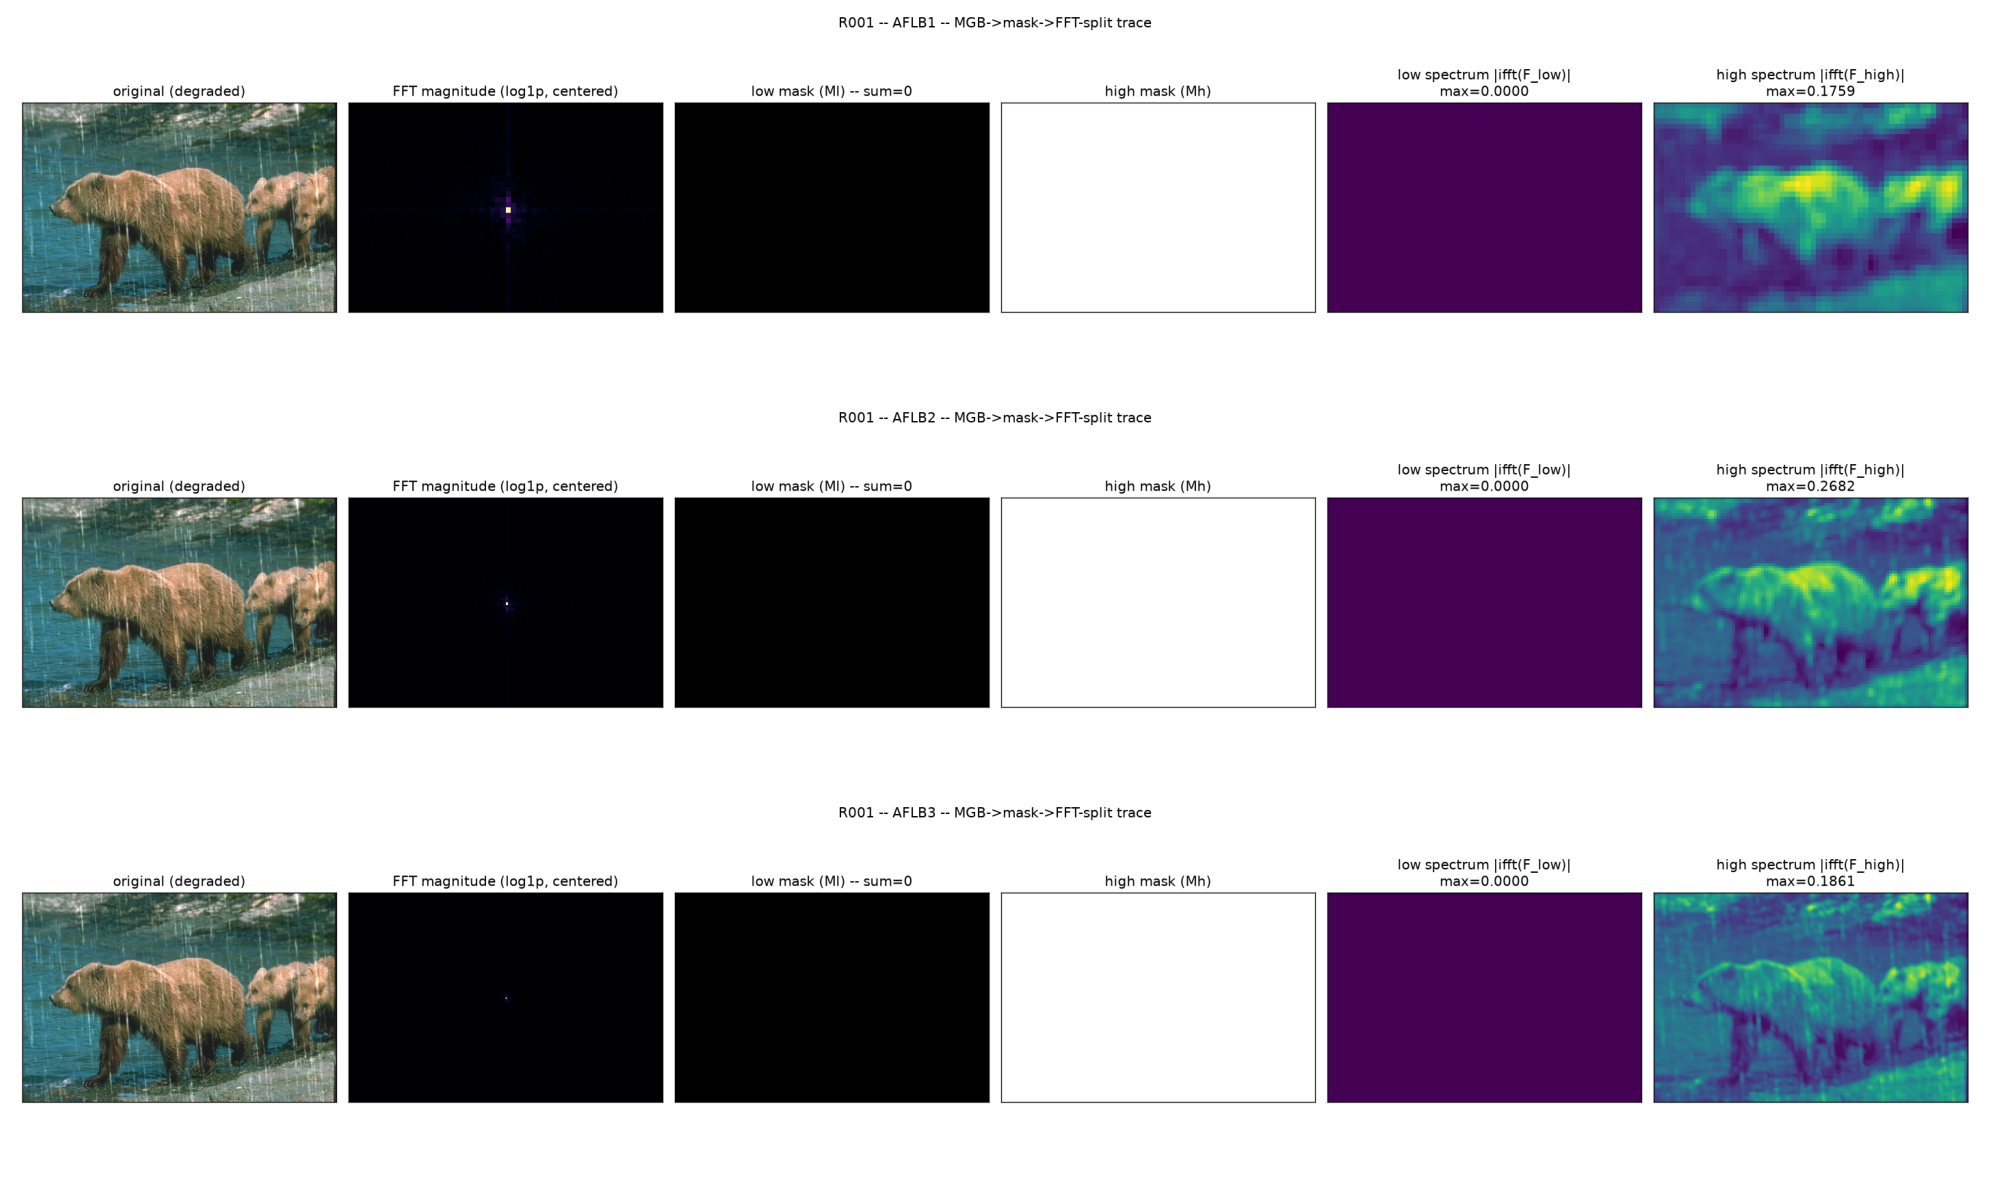

In [15]:
trace_files = sorted((REPO / 'outputs' / 'trace_R001').glob('*_trace.png'))
fig, axes = plt.subplots(len(trace_files), 1, figsize=(20, 4 * len(trace_files)))
if len(trace_files) == 1:
    axes = [axes]
for ax, f in zip(axes, trace_files):
    ax.imshow(mpimg.imread(f)); ax.axis('off')
fig.tight_layout()
plt.show()


FFT magnitude is a tight spike at the centre (DC/near-DC dominance is
expected for natural images); the low mask (Ml) is solid black (0 pixels
selected) at every AFLB; the high mask (Mh) is solid white; "high spectrum"
is essentially the full reconstructed signal, not a genuine high-pass
result — there is no split happening for this image at native resolution.


### A.2 Resolution sweep — when does the mechanism switch on?

Feature-map size at each AFLB is a fixed fraction of the *input* resolution
(three 2x downsamples before the latent): AFLB1 = H/8, AFLB2 = H/4,
AFLB3 = H/2. `h_` only becomes non-zero once `h // 128` climbs high enough
that `int((h // 128) * alpha)` stops truncating to 0 (alpha/beta sit close
to 0.5 in practice, so `h // 128` generally needs to reach ~3). One real
image (`rain-001.png`) was resized up from 128px to 1024px and pushed
through the **full** AdaIR forward pass at each size (1536px/2048px hit
GPU OOM on this 24GB card at fp32/batch=1 and were left untested).


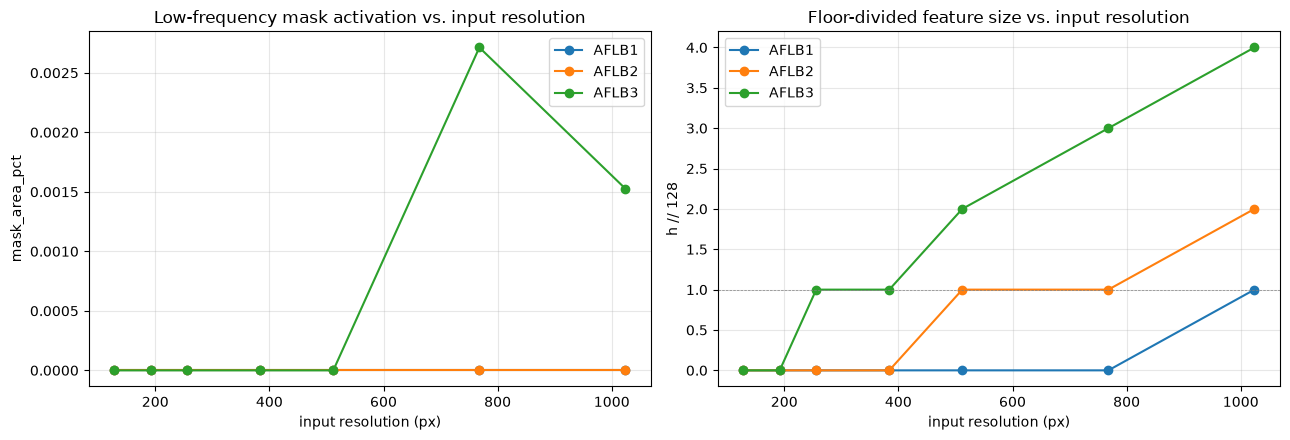

First activating input resolution per AFLB:
  AFLB1: not activated up to 1024px (untested beyond, GPU OOM)
  AFLB2: not activated up to 1024px (untested beyond, GPU OOM)
  AFLB3: 768px


,input_size,AFLB,feature_h,feature_w,h_over_128,w_over_128,alpha,beta,h_half_width,w_half_width,mask_area_pct,mask_active
0,128,AFLB1,16,16,0,0,0.496735,0.504243,0,0,0.000000,False
1,128,AFLB2,32,32,0,0,0.495069,0.497899,0,0,0.000000,False
2,128,AFLB3,64,64,0,0,0.497870,0.498601,0,0,0.000000,False
3,192,AFLB1,24,24,0,0,0.496463,0.504469,0,0,0.000000,False
4,192,AFLB2,48,48,0,0,0.494984,0.497888,0,0,0.000000,False
5,192,AFLB3,96,96,0,0,0.497856,0.498570,0,0,0.000000,False
6,256,AFLB1,32,32,0,0,0.496371,0.504524,0,0,0.000000,False
7,256,AFLB2,64,64,0,0,0.494941,0.497878,0,0,0.000000,False
8,256,AFLB3,128,128,1,1,0.497849,0.498555,0,0,0.000000,False
9,384,AFLB1,48,48,0,0,0.496240,0.504616,0,0,0.000000,False


In [16]:
sweep = _csv('11_Resolution_Sweep')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for aflb in AFLB_ORDER:
    sub = sweep[sweep.AFLB == aflb].sort_values('input_size')
    axes[0].plot(sub.input_size, sub.mask_area_pct, marker='o', label=aflb)
    axes[1].plot(sub.input_size, sub.h_over_128, marker='o', label=aflb)
axes[0].set_xlabel('input resolution (px)'); axes[0].set_ylabel('mask_area_pct')
axes[0].set_title('Low-frequency mask activation vs. input resolution')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('input resolution (px)'); axes[1].set_ylabel('h // 128')
axes[1].set_title('Floor-divided feature size vs. input resolution')
axes[1].axhline(1, color='gray', lw=0.5, ls='--')
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print('First activating input resolution per AFLB:')
for aflb in AFLB_ORDER:
    active = sweep[(sweep.AFLB == aflb) & (sweep.mask_active == True)]
    if len(active):
        print(f'  {aflb}: {int(active.input_size.min())}px')
    else:
        print(f'  {aflb}: not activated up to {int(sweep.input_size.max())}px (untested beyond, GPU OOM)')
sweep


**Empirical thresholds**: AFLB3 (shallowest AFLB, largest feature map)
activates first, at input resolution 768x768. AFLB2 and AFLB1 do not
activate anywhere in the tested range up to 1024x1024 — consistent with
needing roughly 4x and 8x more input resolution respectively (since their
feature maps are 4x and 8x smaller than AFLB3's), which pushes well past
what fits on a 24GB GPU at fp32/batch=1 for this architecture.

**Conclusion**: the mechanism is not fundamentally broken — it is a genuine
adaptive-boundary mechanism that *can* activate — but AdaIR's own published
benchmarks (Rain100L, SOTS, BSD68, all <=~550px) sit far below the
resolution where it ever turns on. This reframes the original question from
"how does the frequency mask differ between Rain/Haze/Noise?" to: **if this
mechanism is inert at benchmark resolution, where does AdaIR's restoration
quality actually come from, and is that mechanism worth distilling into an
NPU student at all?** — the question the next phase of this project (a
teacher mechanism audit, then a resolution/ablation study, before any
student design) is set up to answer.
